In [ ]:
#importing necessary libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

In [ ]:
#loading the processed data
df = pd.read_csv('Data/processed Data/processed_data.csv')

In [ ]:
#separating features and target variable
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
#splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [15]:
#Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [16]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [17]:
#Support Vector Machine
svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

In [18]:
#K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [19]:
#Evaulation function
def evaluate_model(y_test, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("\n")

In [20]:
#Evaluation of all models
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_svm, "Support Vector Machine")
evaluate_model(y_test, y_pred_knn, "K-Nearest Neighbors")

--- Logistic Regression ---
Accuracy: 0.8055358410220014
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

[[939  96]
 [178 196]]


--- Decision Tree ---
Accuracy: 0.730305180979418
              precision    recall  f1-score   support

           0       0.82      0.81      0.81      1035
           1       0.49      0.52      0.50       374

    accuracy                           0.73      1409
   macro avg       0.66      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409

[[836 199]
 [181 193]]


--- Random Forest ---
Accuracy: 0.7828246983676366
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      

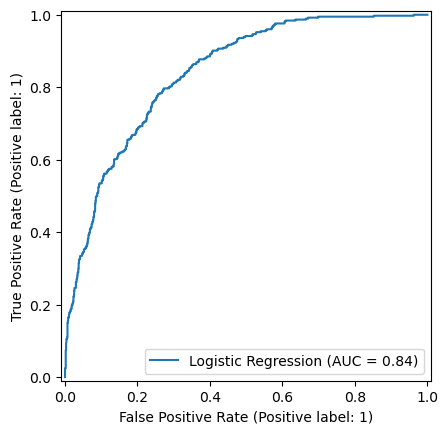

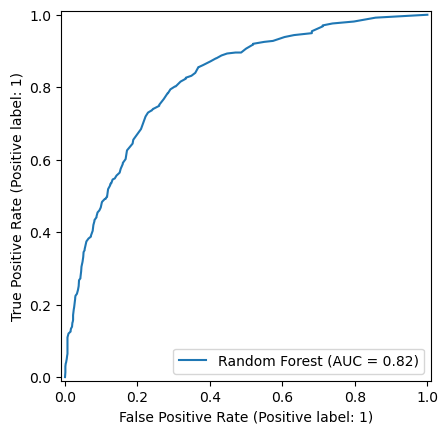

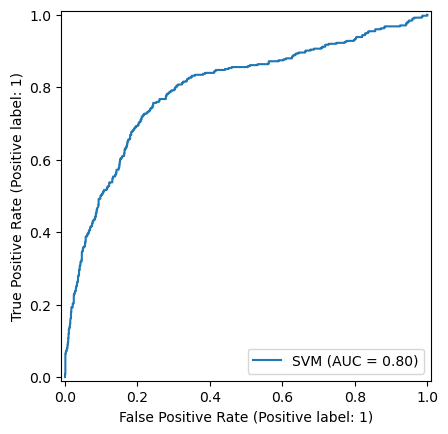

In [21]:
#ROC Curve for Logistic Regression
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "SVM": svm
}

for name, model in models.items():
    if name in ["Logistic Regression", "SVM"]:
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        y_prob = model.predict_proba(X_test)[:,1]

    RocCurveDisplay.from_predictions(y_test, y_prob, name=name)

plt.show()

In [22]:
#Comparing accuracy of all models
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "KNN": accuracy_score(y_test, y_pred_knn)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(results_df.sort_values(by="Accuracy", ascending=False))

                 Model  Accuracy
0  Logistic Regression  0.805536
3                  SVM  0.794890
2        Random Forest  0.782825
4                  KNN  0.762952
1        Decision Tree  0.730305


In [ ]:
#Best model 
best_model = max(results, key=results.get)
print("Best Model:", best_model)

Best Model: Logistic Regression


“Multiple classification models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, SVM, and KNN. Among these, the model with the highest accuracy and balanced performance was selected as the best model.”